# Salient Object Detection (SOD) — Google Colab Notebook

Complete end-to-end pipeline for **Salient Object Detection** using a CNN
encoder-decoder built **from scratch** (no pretrained models).

**What this notebook does (in order):**
1. Mount Google Drive
2. Install required libraries
3. Point to your ECSSD dataset on Drive
4. Define the `SODDataset` class (with augmentation)
5. Define the CNN Encoder-Decoder model
6. Define BCE + 0.5·(1 − IoU) loss
7. Define metrics: IoU, Precision, Recall, F1
8. Train the model + save `best_model.pt` to Drive
9. Evaluate on the test set
10. Visualize: input · ground truth · prediction · overlay

**Expected dataset layout on your Drive:**

```
/content/drive/MyDrive/sod_project/
├── dataset/
│   ├── images/   <- RGB images (.jpg / .png)
│   └── masks/    <- corresponding 1-channel masks (.png)
└── checkpoints/  <- created automatically; best_model.pt will be saved here
```

> Recommended: enable a GPU runtime → **Runtime → Change runtime type → GPU**.


In [ ]:
!unzip -q "/content/drive/MyDrive/sod_project/dataset.zip" -d "/content/drive/MyDrive/sod_project/"

replace /content/drive/MyDrive/sod_project/dataset/images/ILSVRC2012_test_00000004.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace /content/drive/MyDrive/sod_project/dataset/images/ILSVRC2012_test_00000004.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
import os

print("Images:", len(os.listdir("/content/drive/MyDrive/sod_project/dataset/images")))
print("Masks:", len(os.listdir("/content/drive/MyDrive/sod_project/dataset/masks")))

Images: 10553
Masks: 10553


## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Install required libraries

Most of these come pre-installed on Colab. We run `pip install` quietly anyway
so the notebook works on a fresh runtime.


In [ ]:
!pip install -q torch torchvision tqdm matplotlib pillow numpy
print("Libraries ready.")


Libraries ready.


## 3. Configuration — paths and hyperparameters

Edit the paths if your dataset lives elsewhere on Drive.


In [ ]:
import os
import torch

# ---------- Paths on Google Drive ----------
PROJECT_DIR    = "/content/drive/MyDrive/sod_project"
IMAGES_DIR     = os.path.join(PROJECT_DIR, "dataset/images")
MASKS_DIR      = os.path.join(PROJECT_DIR, "dataset/masks")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
RESULTS_DIR    = os.path.join(PROJECT_DIR, "results")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---------- Hyperparameters ----------
IMAGE_SIZE   = 224
BATCH_SIZE   = 8
NUM_WORKERS  = 0
EPOCHS       = 25
LEARNING_RATE = 1e-3
PATIENCE     = 10        # early-stop if val loss doesn't improve for N epochs
SEED         = 42
DROPOUT_P    = 0.3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ---------- Sanity check the dataset ----------
assert os.path.isdir(IMAGES_DIR), f"Images folder not found: {IMAGES_DIR}"
assert os.path.isdir(MASKS_DIR),  f"Masks folder not found: {MASKS_DIR}"
n_imgs  = len([f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))])
n_masks = len([f for f in os.listdir(MASKS_DIR)  if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))])
print(f"Found {n_imgs} images and {n_masks} masks.")


Device: cuda
Found 10553 images and 10553 masks.


## 4. `SODDataset` — load and augment image/mask pairs

- Resizes images and masks to `IMAGE_SIZE × IMAGE_SIZE`
- Normalizes images to `[0, 1]`
- Binarizes masks (foreground = 1, background = 0)
- Augmentation (training only): random horizontal flip, brightness, random crop
- Splits into 70% / 15% / 15% (train / val / test)

Image and mask filenames must match (e.g. `0001.jpg` ↔ `0001.png`).


In [ ]:
import os
import random
from PIL import Image, ImageEnhance
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as TF


class SODDataset(Dataset):
    """Custom Dataset for Salient Object Detection."""

    def __init__(self, images_dir, masks_dir, image_size=128, augment=False):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_size = image_size
        self.augment = augment

        self.image_files = sorted([
            f for f in os.listdir(images_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
        ])

    def __len__(self):
        return len(self.image_files)

    def _get_mask_path(self, image_filename):
        """Find the matching mask by trying common extensions."""
        name, _ = os.path.splitext(image_filename)
        for ext in (".png", ".jpg", ".jpeg", ".bmp"):
            candidate = os.path.join(self.masks_dir, name + ext)
            if os.path.exists(candidate):
                return candidate
        return os.path.join(self.masks_dir, name + ".png")  # fallback

    def _augment(self, image, mask):
        # 1. Random horizontal flip
        if random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)
        # 2. Random brightness change (image only)
        if random.random() < 0.5:
            factor = random.uniform(0.7, 1.3)
            image = ImageEnhance.Brightness(image).enhance(factor)
        # 3. Random crop + resize back (random zoom effect)
        if random.random() < 0.5:
            crop_size = int(self.image_size * random.uniform(0.8, 1.0))
            i = random.randint(0, self.image_size - crop_size)
            j = random.randint(0, self.image_size - crop_size)
            image = TF.crop(image, i, j, crop_size, crop_size)
            mask  = TF.crop(mask,  i, j, crop_size, crop_size)
            image = TF.resize(image, [self.image_size, self.image_size])
            mask  = TF.resize(mask,  [self.image_size, self.image_size])
        return image, mask

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = self._get_mask_path(img_name)

        image = Image.open(img_path).convert("RGB")
        mask  = Image.open(mask_path).convert("L")

        # Resize to a fixed size
        image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask  = mask.resize((self.image_size, self.image_size), Image.NEAREST)

        if self.augment:
            image, mask = self._augment(image, mask)

        # PIL -> Tensor (also normalizes to [0, 1])
        image = TF.to_tensor(image)            # (3, H, W)
        mask  = TF.to_tensor(mask)             # (1, H, W)
        mask  = (mask > 0.5).float()           # binarize

        return image, mask


def get_dataloaders(images_dir, masks_dir, image_size=128, batch_size=16,
                    num_workers=2, seed=42):
    """Build train / val / test DataLoaders with a 70/15/15 split."""
    full_aug   = SODDataset(images_dir, masks_dir, image_size, augment=True)
    full_clean = SODDataset(images_dir, masks_dir, image_size, augment=False)

    total = len(full_aug)
    n_train = int(0.70 * total)
    n_val   = int(0.15 * total)
    n_test  = total - n_train - n_val

    g = torch.Generator().manual_seed(seed)
    train_set, val_set, test_set = random_split(full_aug, [n_train, n_val, n_test], generator=g)

    # Use the non-augmented dataset for val/test (fair evaluation)
    val_set.dataset  = full_clean
    test_set.dataset = full_clean

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    print(f"Split -> Train: {n_train} | Val: {n_val} | Test: {n_test}")
    return train_loader, val_loader, test_loader


# Build the loaders
train_loader, val_loader, test_loader = get_dataloaders(
    IMAGES_DIR, MASKS_DIR,
    image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS, seed=SEED,
)

# Quick sanity check — peek at one batch
for imgs, masks in train_loader:
    print("Image batch:", imgs.shape, "range:", imgs.min().item(), imgs.max().item())
    print("Mask batch :", masks.shape, "range:", masks.min().item(), masks.max().item())
    break


Split -> Train: 7387 | Val: 1582 | Test: 1584
Image batch: torch.Size([8, 3, 224, 224]) range: 0.0 1.0
Mask batch : torch.Size([8, 1, 224, 224]) range: 0.0 1.0


## 5. Model — CNN Encoder-Decoder (from scratch)

- **Encoder**: 4 Conv blocks (Conv → BatchNorm → ReLU → MaxPool)
- **Bottleneck**: Conv + BatchNorm + ReLU + **Dropout** (regularization)
- **Decoder**: 4 ConvTranspose blocks (upsampling)
- **Output**: 1×1 Conv + Sigmoid → 1-channel mask in `[0, 1]`

Improvements built in (project requirement #8):
1. **BatchNorm** after every Conv layer
2. **Dropout** in the bottleneck


In [ ]:
import torch.nn as nn


class ConvBlock(nn.Module):
    """Conv -> BN -> ReLU"""
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class UpBlock(nn.Module):
    """ConvTranspose -> BN -> ReLU (upsamples by 2x)"""
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class SODModel(nn.Module):
    """CNN Encoder-Decoder for Salient Object Detection."""
    def __init__(self, in_channels=3, out_channels=1, dropout_p=0.3):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock(in_channels, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.enc4 = ConvBlock(128, 256)
        self.pool = nn.MaxPool2d(2, 2)

        # Bottleneck (with Dropout)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p),
        )

        # Decoder
        self.up1 = UpBlock(256, 128)
        self.up2 = UpBlock(128, 64)
        self.up3 = UpBlock(64, 32)
        self.up4 = UpBlock(32, 16)

        # Output
        self.out_conv = nn.Conv2d(16, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(self.enc1(x))   # 128 -> 64
        x = self.pool(self.enc2(x))   # 64  -> 32
        x = self.pool(self.enc3(x))   # 32  -> 16
        x = self.pool(self.enc4(x))   # 16  -> 8
        x = self.bottleneck(x)
        x = self.up1(x)               # 8  -> 16
        x = self.up2(x)               # 16 -> 32
        x = self.up3(x)               # 32 -> 64
        x = self.up4(x)               # 64 -> 128
        return self.sigmoid(self.out_conv(x))


# Quick sanity check
model = SODModel(dropout_p=DROPOUT_P).to(DEVICE)
dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print("Input :", dummy.shape)
print("Output:", out.shape, "range:", out.min().item(), out.max().item())
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Input : torch.Size([2, 3, 224, 224])
Output: torch.Size([2, 1, 224, 224]) range: 0.12821383774280548 0.8268979787826538
Total parameters: 1,154,785


## 6. Loss — BCE + 0.5 · (1 − IoU)

Combined loss: pixel-wise Binary Cross-Entropy plus a soft IoU term that
encourages the predicted mask to overlap well with the ground truth.


In [ ]:
import torch.nn.functional as F


def iou_score(pred, target, eps=1e-6):
    """Soft IoU on probabilities (differentiable). Returns scalar averaged over batch."""
    pred   = pred.contiguous().view(pred.size(0), -1)
    target = target.contiguous().view(target.size(0), -1)
    intersection = (pred * target).sum(dim=1)
    union = pred.sum(dim=1) + target.sum(dim=1) - intersection
    return ((intersection + eps) / (union + eps)).mean()


class BCE_IoU_Loss(nn.Module):
    """L = BCE(pred, target) + 0.5 * (1 - IoU(pred, target))"""
    def __init__(self, iou_weight=0.5):
        super().__init__()
        self.bce = nn.BCELoss()
        self.iou_weight = iou_weight

    def forward(self, pred, target):
        return self.bce(pred, target) + self.iou_weight * (1.0 - iou_score(pred, target))


criterion = BCE_IoU_Loss(iou_weight=0.5)
print("Loss function ready: BCE + 0.5 * (1 - IoU)")


Loss function ready: BCE + 0.5 * (1 - IoU)


## 7. Metrics — IoU, Precision, Recall, F1

Predictions are binarized at threshold = 0.5 before computing the metrics.


In [ ]:
def compute_metrics(pred, target, threshold=0.5, eps=1e-6):
    """Compute IoU, Precision, Recall, F1 for a batch of predictions."""
    pred_bin = (pred > threshold).float()
    target = target.float()

    pred_flat   = pred_bin.view(pred_bin.size(0), -1)
    target_flat = target.view(target.size(0), -1)

    tp = (pred_flat * target_flat).sum(dim=1)
    fp = (pred_flat * (1 - target_flat)).sum(dim=1)
    fn = ((1 - pred_flat) * target_flat).sum(dim=1)

    iou       = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall    = (tp + eps) / (tp + fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)

    return {
        "iou":       iou.mean().item(),
        "precision": precision.mean().item(),
        "recall":    recall.mean().item(),
        "f1":        f1.mean().item(),
    }


print("Metrics function ready.")


Metrics function ready.


## 8. Train — full loop with validation + best-model saving

- Forward pass → loss → backward pass → optimizer step
- Validation after each epoch
- Saves `best_model.pt` to Drive whenever validation loss improves
- `tqdm` progress bars
- Simple early stopping (`PATIENCE` epochs)


In [ ]:
import torch.optim as optim
from tqdm.auto import tqdm

torch.manual_seed(SEED)


def train_one_epoch(model, loader, criterion, optimizer, device, epoch, total_epochs):
    model.train()
    running_loss = 0.0
    pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs} [Train]", leave=False)
    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return running_loss / len(loader.dataset)


@torch.no_grad()
def validate(model, loader, criterion, device, epoch, total_epochs):
    model.eval()
    running_loss = 0.0
    metric_sums = {"iou": 0.0, "precision": 0.0, "recall": 0.0, "f1": 0.0}
    n_batches = 0
    pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs} [Val]  ", leave=False)
    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)
        preds = model(images)
        loss = criterion(preds, masks)
        running_loss += loss.item() * images.size(0)
        m = compute_metrics(preds, masks)
        for k in metric_sums: metric_sums[k] += m[k]
        n_batches += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}", iou=f"{m['iou']:.3f}")
    avg_loss = running_loss / len(loader.dataset)
    avg_metrics = {k: v / max(n_batches, 1) for k, v in metric_sums.items()}
    return avg_loss, avg_metrics


# Re-init model + optimizer (lets you re-run this cell to train from scratch)
model = SODModel(dropout_p=DROPOUT_P).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_val_loss = float("inf")
epochs_no_improve = 0
best_path = os.path.join(CHECKPOINT_DIR, "best_model.pt")
history = []  # for plotting later

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer,
                                  DEVICE, epoch, EPOCHS)
    val_loss, val_metrics = validate(model, val_loader, criterion,
                                      DEVICE, epoch, EPOCHS)

    history.append({
        "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
        **val_metrics,
    })

    print(f"Epoch {epoch:03d}/{EPOCHS} | "
          f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
          f"IoU: {val_metrics['iou']:.4f} | "
          f"P: {val_metrics['precision']:.4f} | "
          f"R: {val_metrics['recall']:.4f} | "
          f"F1: {val_metrics['f1']:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
        }, best_path)
        print(f"  ✔ New best! Saved -> {best_path}")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

print(f"\nTraining complete. Best validation loss: {best_val_loss:.4f}")
print(f"Best model saved to: {best_path}")


Epoch 1/25 [Train]:   0%|          | 0/924 [00:00<?, ?it/s]

Epoch 1/25 [Val]  :   0%|          | 0/198 [00:00<?, ?it/s]

Epoch 001/25 | Train: 0.7889 | Val: 0.7006 | IoU: 0.4996 | P: 0.6437 | R: 0.7331 | F1: 0.6387
  ✔ New best! Saved -> /content/drive/MyDrive/sod_project/checkpoints/best_model.pt


Epoch 2/25 [Train]:   0%|          | 0/924 [00:00<?, ?it/s]

Epoch 2/25 [Val]  :   0%|          | 0/198 [00:00<?, ?it/s]

...

Epoch 24/25 [Val]  :   0%|          | 0/198 [00:00<?, ?it/s]

Epoch 024/25 | Train: 0.4604 | Val: 0.4739 | IoU: 0.6766 | P: 0.7433 | R: 0.8965 | F1: 0.7847
  No improvement for 2 epoch(s).


Epoch 25/25 [Train]:   0%|          | 0/924 [00:00<?, ?it/s]

Epoch 25/25 [Val]  :   0%|          | 0/198 [00:00<?, ?it/s]

Epoch 025/25 | Train: 0.4554 | Val: 0.4822 | IoU: 0.6709 | P: 0.7360 | R: 0.8970 | F1: 0.7792
  No improvement for 3 epoch(s).

Training complete. Best validation loss: 0.4576
Best model saved to: /content/drive/MyDrive/sod_project/checkpoints/best_model.pt


## 8b. (Optional) Plot training curves

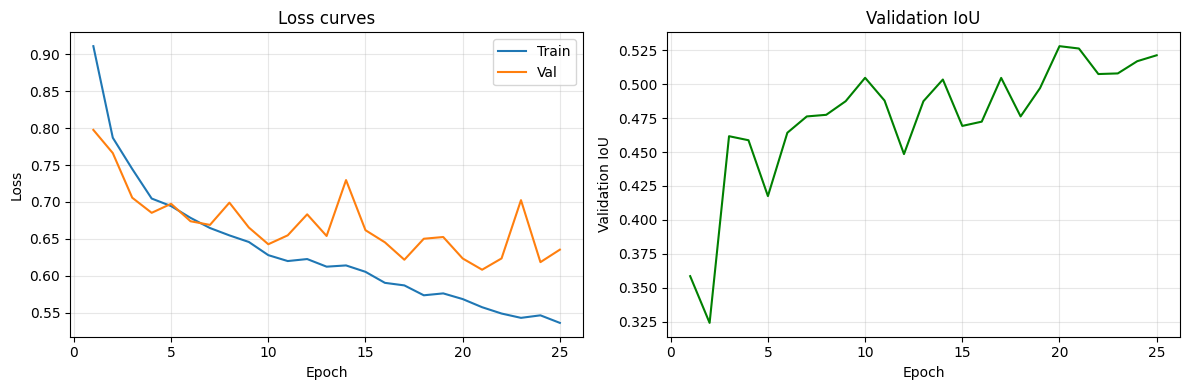

In [ ]:
import matplotlib.pyplot as plt

if history:
    epochs_x  = [h["epoch"]      for h in history]
    train_ls  = [h["train_loss"] for h in history]
    val_ls    = [h["val_loss"]   for h in history]
    val_ious  = [h["iou"]        for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs_x, train_ls, label="Train")
    axes[0].plot(epochs_x, val_ls,   label="Val")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss curves")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_x, val_ious, color="green")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation IoU")
    axes[1].set_title("Validation IoU"); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()
else:
    print("No training history to plot. Run the training cell first.")


## 9. Evaluate on the test set

Loads the best checkpoint and reports IoU, Precision, Recall, F1
averaged over the held-out test split.


In [ ]:
# Load best model
ckpt = torch.load(best_path, map_location=DEVICE)
model = SODModel(dropout_p=DROPOUT_P).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded best checkpoint from epoch {ckpt.get('epoch', '?')}.")


@torch.no_grad()
def evaluate(model, loader, device):
    """Run on the loader, return averaged metrics + per-sample records for visualization."""
    model.eval()
    metric_sums = {"iou": 0.0, "precision": 0.0, "recall": 0.0, "f1": 0.0}
    total = 0
    samples = []   # (img, gt, pred, sample_iou)

    for images, masks in tqdm(loader, desc="Evaluating on test set"):
        images, masks = images.to(device), masks.to(device)
        preds = model(images)

        m = compute_metrics(preds, masks)
        bs = images.size(0)
        for k in metric_sums: metric_sums[k] += m[k] * bs
        total += bs

        # Per-sample IoU (so we can show best/worst examples)
        preds_bin = (preds > 0.5).float()
        pf = preds_bin.view(bs, -1); mf = masks.view(bs, -1)
        inter = (pf * mf).sum(dim=1)
        union = pf.sum(dim=1) + mf.sum(dim=1) - inter
        sample_iou = ((inter + 1e-6) / (union + 1e-6)).cpu().tolist()

        imgs_cpu = images.cpu(); gts_cpu = masks.cpu(); prs_cpu = preds.cpu()
        for i in range(bs):
            samples.append((imgs_cpu[i], gts_cpu[i], prs_cpu[i], sample_iou[i]))

    avg = {k: v / max(total, 1) for k, v in metric_sums.items()}
    return avg, total, samples


metrics, n_test, samples = evaluate(model, test_loader, DEVICE)

print("\n=========== Test Set Results ===========")
print(f"Samples evaluated : {n_test}")
print(f"IoU       : {metrics['iou']:.4f}")
print(f"Precision : {metrics['precision']:.4f}")
print(f"Recall    : {metrics['recall']:.4f}")
print(f"F1 Score  : {metrics['f1']:.4f}")
print("========================================")


Loaded best checkpoint from epoch 22.


Evaluating on test set:   0%|          | 0/198 [00:00<?, ?it/s]


=========== Test Set Results ===========
Samples evaluated : 1584
IoU       : 0.6798
Precision : 0.7757
Recall    : 0.8593
F1 Score  : 0.7872


## 10. Visualize predictions

Four columns per row: **input · ground truth · prediction · overlay**.

We show three figures:
- `best_predictions.png` — highest-IoU samples
- `worst_predictions.png` — lowest-IoU samples (failure cases)
- `random_predictions.png` — unbiased random selection

All three are saved to `/content/drive/MyDrive/sod_project/results/`.



Best predictions  (IoUs: [0.855, 0.854, 0.833, 0.819])
Saved: /content/drive/MyDrive/sod_project/results/best_predictions.png


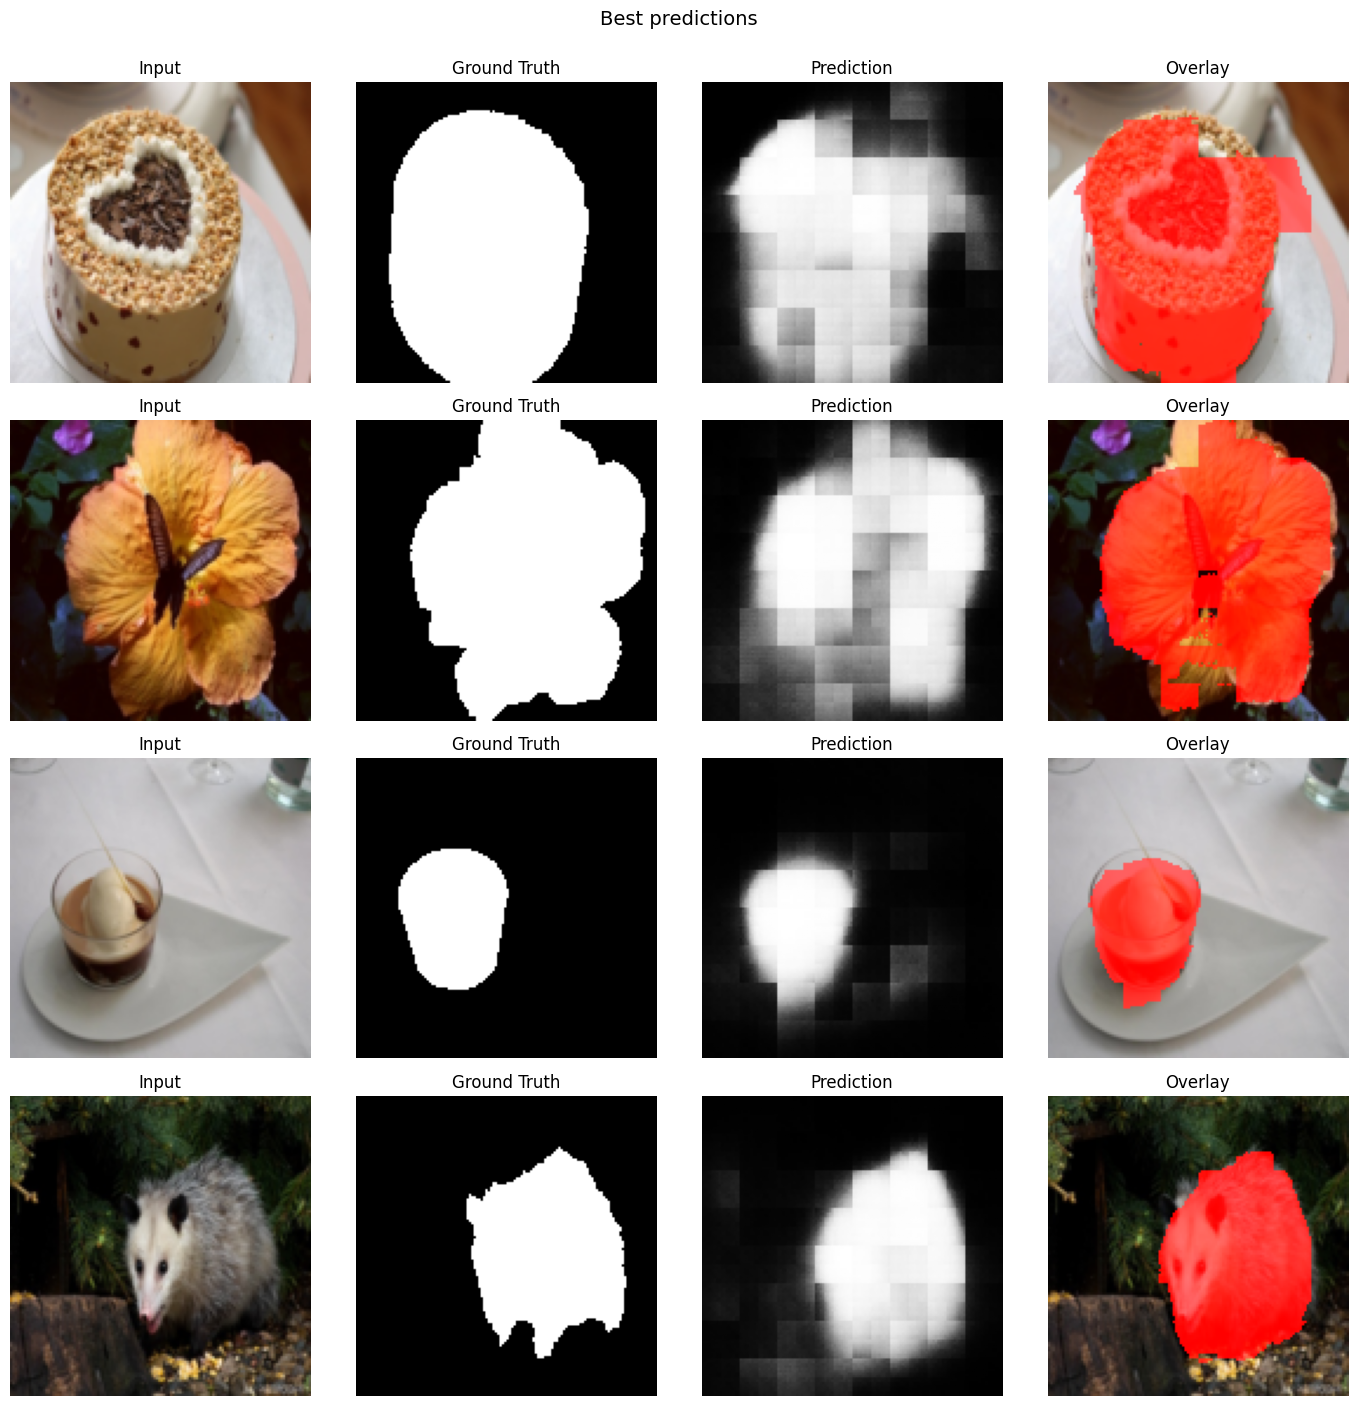


Worst predictions (IoUs: [0.024, 0.084, 0.086, 0.089])
Saved: /content/drive/MyDrive/sod_project/results/worst_predictions.png


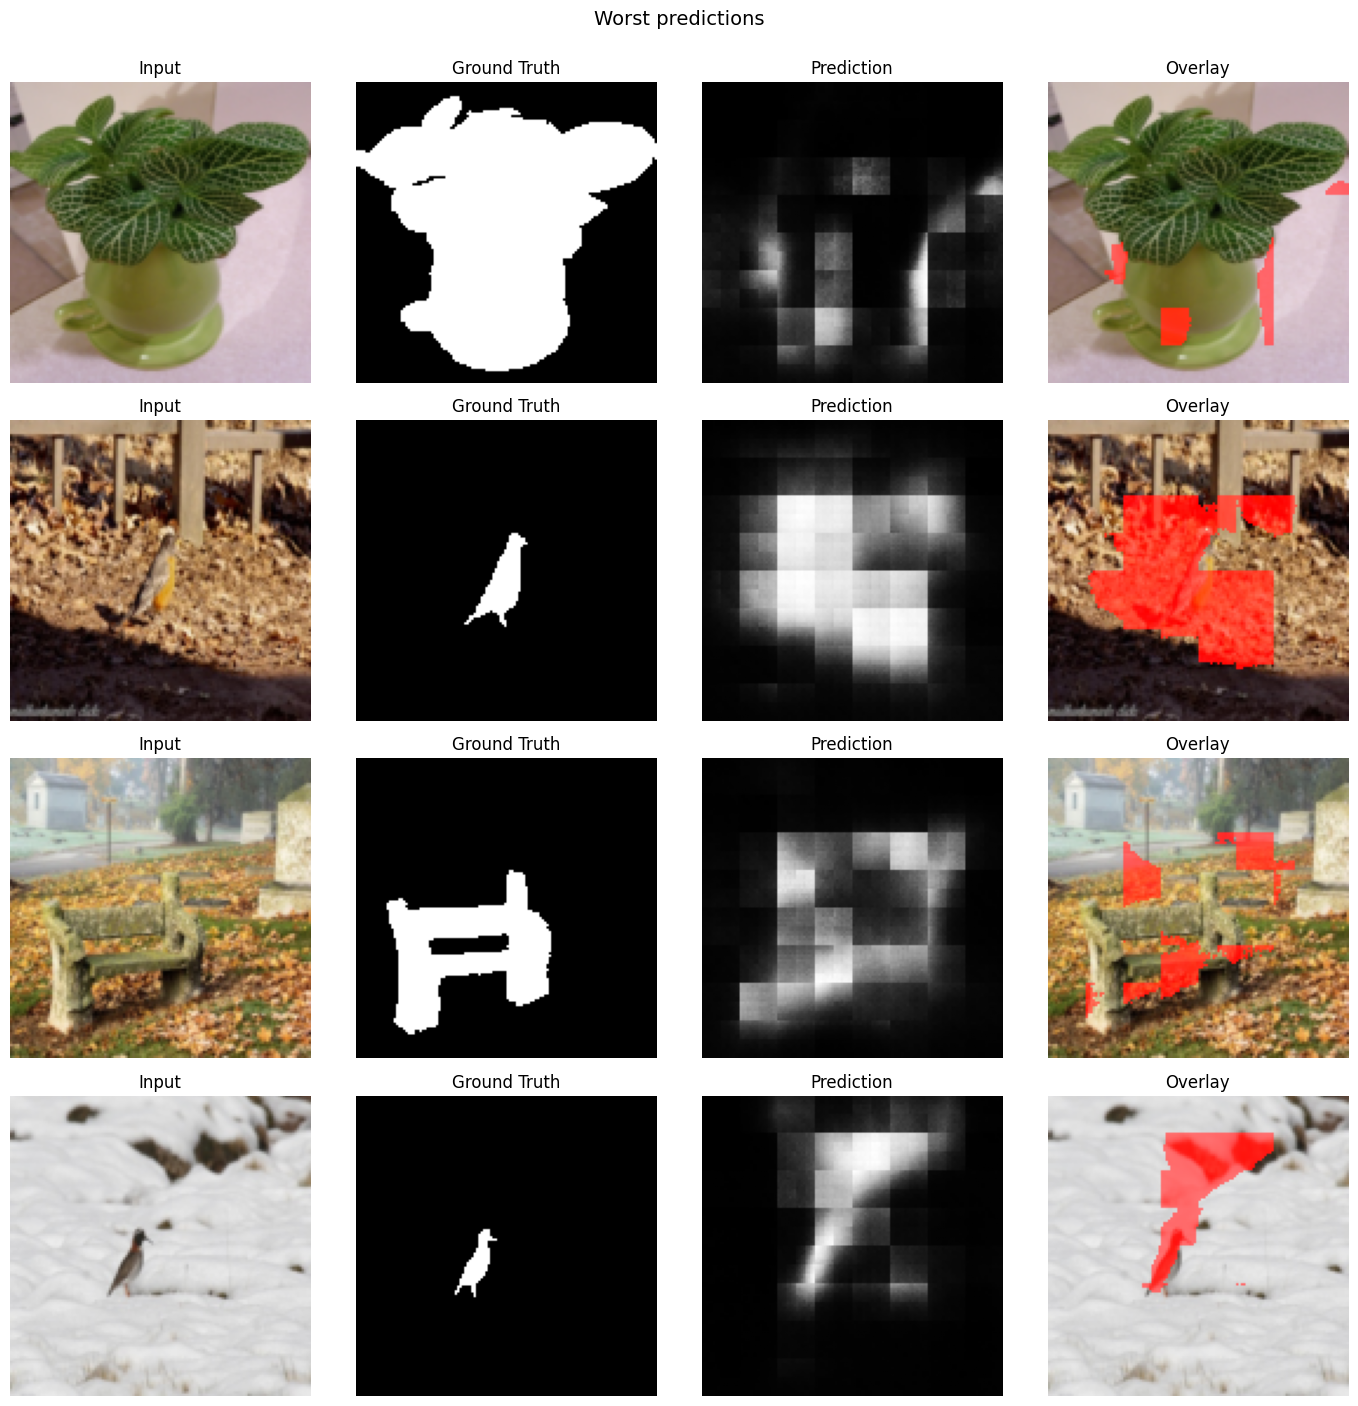


Random predictions (IoUs: [0.273, 0.616, 0.502, 0.42])
Saved: /content/drive/MyDrive/sod_project/results/random_predictions.png


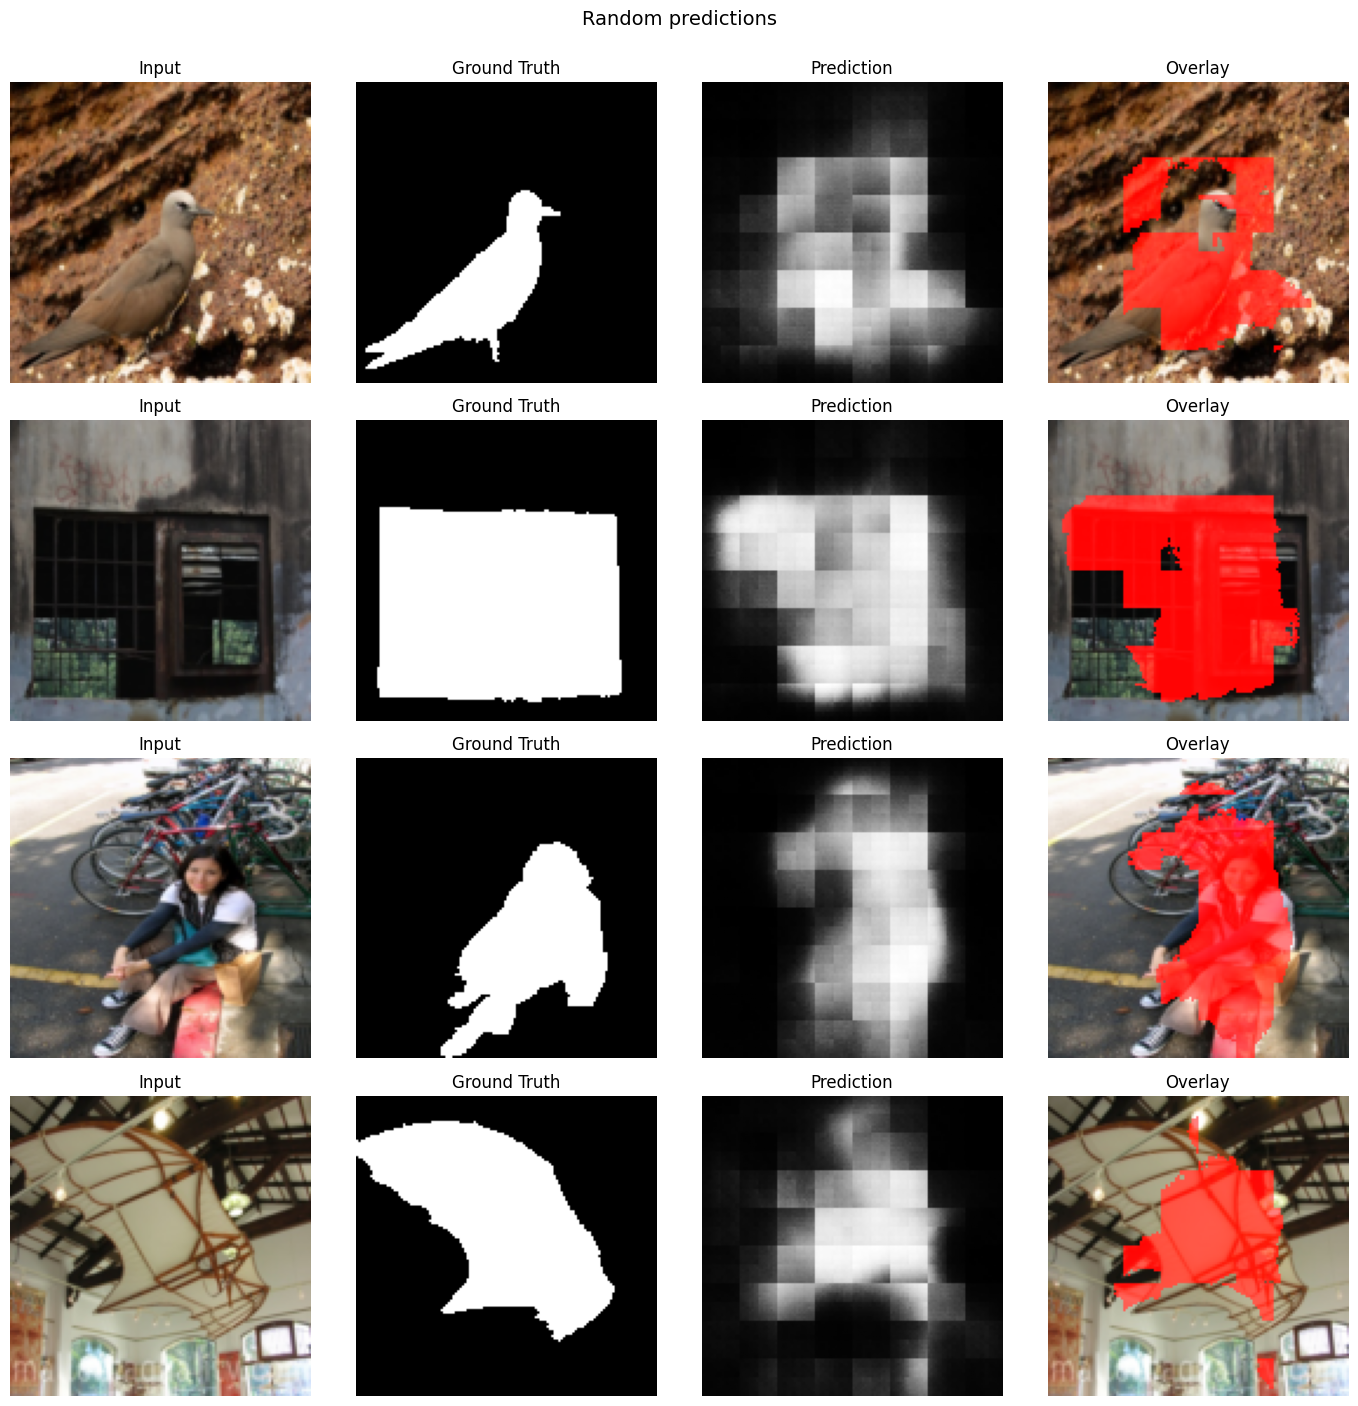


All visualizations saved to: /content/drive/MyDrive/sod_project/results


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt


def visualize_predictions(images, gt_masks, pred_masks, num_samples=4, save_path=None, title=None):
    """Plot input | GT | prediction | overlay for a batch of samples."""
    num_samples = min(num_samples, images.size(0))
    fig, axes = plt.subplots(num_samples, 4, figsize=(14, 3.5 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, 0)

    for i in range(num_samples):
        img_np = images[i].cpu().numpy().transpose(1, 2, 0)
        img_np = np.clip(img_np, 0, 1)
        gt_np   = gt_masks[i, 0].cpu().numpy()
        pred_np = pred_masks[i, 0].cpu().numpy()
        pred_bin = (pred_np > 0.5).astype(np.float32)

        # Red overlay where prediction is salient
        overlay = img_np.copy()
        overlay[..., 0] = np.where(pred_bin > 0.5, 1.0, overlay[..., 0])
        overlay[..., 1] = np.where(pred_bin > 0.5, overlay[..., 1] * 0.5, overlay[..., 1])
        overlay[..., 2] = np.where(pred_bin > 0.5, overlay[..., 2] * 0.5, overlay[..., 2])

        axes[i, 0].imshow(img_np);              axes[i, 0].set_title("Input");        axes[i, 0].axis("off")
        axes[i, 1].imshow(gt_np,   cmap="gray"); axes[i, 1].set_title("Ground Truth"); axes[i, 1].axis("off")
        axes[i, 2].imshow(pred_np, cmap="gray"); axes[i, 2].set_title("Prediction");   axes[i, 2].axis("off")
        axes[i, 3].imshow(overlay);             axes[i, 3].set_title("Overlay");      axes[i, 3].axis("off")

    if title: fig.suptitle(title, fontsize=14, y=1.001)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


def stack(records):
    return (
        torch.stack([r[0] for r in records]),
        torch.stack([r[1] for r in records]),
        torch.stack([r[2] for r in records]),
    )


NUM_VISUALIZE = 4
sorted_samples = sorted(samples, key=lambda r: r[3], reverse=True)
k = min(NUM_VISUALIZE, len(sorted_samples))

# Best predictions
best = sorted_samples[:k]
imgs, gts, prs = stack(best)
print(f"\nBest predictions  (IoUs: {[round(r[3], 3) for r in best]})")
visualize_predictions(imgs, gts, prs, num_samples=k,
                      save_path=os.path.join(RESULTS_DIR, "best_predictions.png"),
                      title="Best predictions")

# Worst predictions
worst = sorted_samples[-k:][::-1]
imgs, gts, prs = stack(worst)
print(f"\nWorst predictions (IoUs: {[round(r[3], 3) for r in worst]})")
visualize_predictions(imgs, gts, prs, num_samples=k,
                      save_path=os.path.join(RESULTS_DIR, "worst_predictions.png"),
                      title="Worst predictions")

# Random predictions
rng = random.Random(SEED)
rand = rng.sample(samples, k)
imgs, gts, prs = stack(rand)
print(f"\nRandom predictions (IoUs: {[round(r[3], 3) for r in rand]})")
visualize_predictions(imgs, gts, prs, num_samples=k,
                      save_path=os.path.join(RESULTS_DIR, "random_predictions.png"),
                      title="Random predictions")

print(f"\nAll visualizations saved to: {RESULTS_DIR}")


## 11. (Optional) Single-image demo

Pick any image on Drive (or upload one with the file uploader below) and run
the model on it.


Predicting on: /content/drive/MyDrive/sod_project/dataset/images/0001.jpg


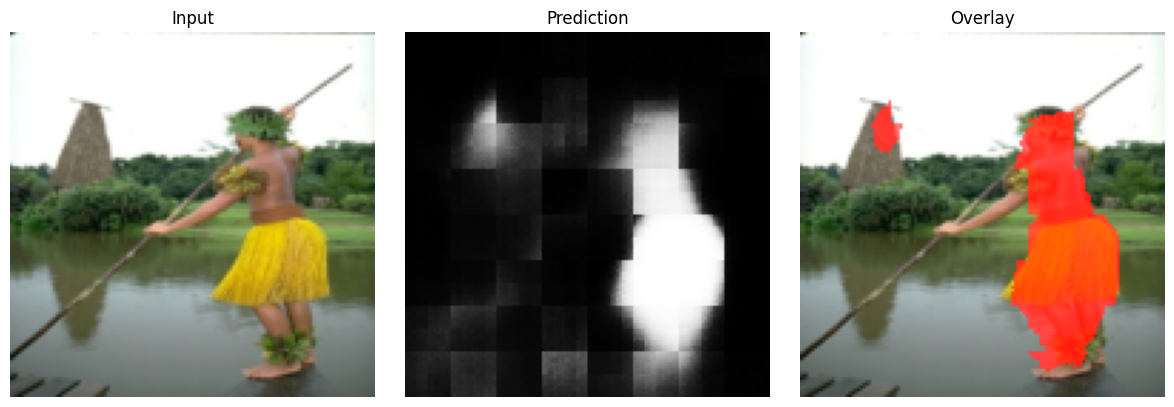

Inference time: 17.89 ms


In [ ]:
from PIL import Image
import torchvision.transforms.functional as TF
import time


def predict_single(image_path, model=model, size=IMAGE_SIZE):
    pil = Image.open(image_path).convert("RGB").resize((size, size), Image.BILINEAR)
    tensor = TF.to_tensor(pil).unsqueeze(0).to(DEVICE)

    start = time.time()
    with torch.no_grad():
        pred = model(tensor)
    ms = (time.time() - start) * 1000.0

    pred_np = pred.squeeze().cpu().numpy()
    img_np = np.array(pil).astype(np.float32) / 255.0
    binary = (pred_np > 0.5).astype(np.float32)
    overlay = img_np.copy()
    overlay[..., 0] = np.where(binary > 0.5, 1.0, overlay[..., 0])
    overlay[..., 1] = np.where(binary > 0.5, overlay[..., 1] * 0.5, overlay[..., 1])
    overlay[..., 2] = np.where(binary > 0.5, overlay[..., 2] * 0.5, overlay[..., 2])

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_np);              axes[0].set_title("Input");      axes[0].axis("off")
    axes[1].imshow(pred_np, cmap="gray"); axes[1].set_title("Prediction"); axes[1].axis("off")
    axes[2].imshow(overlay);             axes[2].set_title("Overlay");    axes[2].axis("off")
    plt.tight_layout(); plt.show()
    print(f"Inference time: {ms:.2f} ms")


# 👉 Edit this path or comment it out and use the uploader cell below
IMAGE_PATH = os.path.join(IMAGES_DIR, sorted(os.listdir(IMAGES_DIR))[0])
print(f"Predicting on: {IMAGE_PATH}")
predict_single(IMAGE_PATH)


### Or upload an image from your computer

In [ ]:
# Uncomment to upload an image from your local machine
# from google.colab import files
# uploaded = files.upload()
# for filename in uploaded.keys():
#     print(f"\nPredicting on uploaded file: {filename}")
#     predict_single(filename)


## ✅ Done

Outputs saved on Drive:
- **Best model**: `/content/drive/MyDrive/sod_project/checkpoints/best_model.pt`
- **Visualizations**: `/content/drive/MyDrive/sod_project/results/`

**Next steps:**
- Try more epochs or a smaller learning rate to push metrics higher.
- Experiment with adding skip connections (U-Net style) for sharper masks.
- Compare a baseline (no BatchNorm / no Dropout) vs the improved version for the
  Experiments & Improvements section of your report.


Github:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

'Book - Digital electronics A practical approach with VHDL.pdf'
'Colab Notebooks'
'CV ROZA 2025 (1).pdf'
'CV ROZA 2025 English.pdf'
'CV ROZA 2025.pdf'
'CV ROZAFA HAJRIZI - 2026.pdf'
 DEMO.mp4
'Dëshmi e Ndërprerjes së Trajnimit (1).docx'
'DETYRA 10,11,12.pdf'
'DETYRA 13.pdf'
'DETYRA 14.pdf'
'DETYRA 15.pdf'
'DETYRA 17.pdf'
'DETYRA 18.pdf'
'DETYRA 9.pdf'
 PerAlbinen.gdoc
 PerBlineren.gdoc
 PerGenten.gdoc
'PerGresen .gdoc'
'Planifikimi per vendosjen e materialeve dhe instrumentet e vlerësimit.xlsm'
 SHENIMET.zip
 sod_project
'Untitled Diagram (1).drawio'
'Untitled Diagram (2).drawio'
'Untitled Diagram.drawio'
